# Fixed vs. adaptive deposition schemes

When depositing particle data onto a grid, `smudgy` supports two broad
categories of assignment schemes:

- **Fixed (non-adaptive) schemes**: The kernel support size is set
  entirely by the grid spacing, independent of the local particle
  distribution. These correspond to the classical particle-mesh (PM)
  assignment schemes such as Nearest Grid Point (NGP), Cloud-in-Cell (CIC), and Triangular Shaped Cloud (TSC), as well as higher-order piecewise cubic and quintic splines.
- **Adaptive schemes**: This is the default behaviour in `smudgy`
  (`adaptive=True`), where the kernel support is determined
  per-particle from the local density environment, typically via a
  smoothing length or tensor estimated from the distance to a fixed number of nearest neighbours.

The key practical difference between the two is that fixed schemes require **no smoothing length** at all, since the kernel size is already fully determined by the grid geometry. Adaptive schemes, on the other hand, require an explicit {py:meth}`~smudgy.pointcloud.PointCloud.compute_smoothing` step beforehand, which determines each particle's local kernel size.

In this tutorial we first introduce the fixed schemes, deposit a toy
dataset with each of them, and compare the results side by side. We then
move on to adaptive kernels, and compare how the *kernel* (`kernel_name`) and *structure* (`separable`, `isotropic`, `covariant`) affect the final result.

First, we import the necessary packages and modules.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import smudgy as sm

np.random.seed(0)

[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.13.14


[I 08/19/26 22:38:50.387 4810772] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [2]:
try:
    plt.style.use('custom')
except:
    pass

%matplotlib inline
%config InlineBackend.figure_format='retina'

Next, we initialize a random toy dataset and set up a {py:class}`~smudgy.pointcloud.PointCloud`
object. For this tutorial we omit periodic boundary conditions. The
`num_neighbors` parameter is only used later, when we compute adaptive
smoothing lengths.

In [3]:
# Define parameters for the point cloud
N = 10
boxsize = 1.0

# Generate random positions and masses for the point cloud
positions = np.random.uniform(0.1 * boxsize, 0.9 * boxsize, (N, 2))

# init smudgy object
pc = sm.PointCloud(
    positions=positions,
    boxsize=boxsize,
    verbose=False,
    arch='cpu'
    )

# store fixed kwargs for later use
kwargs = dict(
    fields=pc.weights,
    averaged=False,
    extent=[[0, boxsize], [0, boxsize]],
    return_weights=True,
)

[Taichi] Starting on arch=arm64


## Fixed (non-adaptive) deposition schemes

The following fixed assignment schemes are available in `smudgy`:

| Scheme | Order | `kernel_name` |
|:--|:-:|:-:|
| Nearest Grid Point (NGP) | 0 | `"ngp"` |
| Cloud-in-Cell (CIC) | 1 | `"cic"` |
| Triangular Shaped Cloud (TSC) | 2 | `"tsc"` |
| Piecewise cubic spline | 3 | `"pcs"` |
| Piecewise quintic spline | 5 | `"pqs"` |

Below we compare the resulting deposition grids for all available orders in `smudgy`.

In [4]:
ADAPTIVE = False

gridnums = 20
structure = 'separable'
kernel_names = ['ngp', 'cic', 'tsc', 'pcs', 'pqs']
kernel_labels = [
    'Nearest Grid Point', 
    'Cloud-in-Cell', 
    'Triangular Shaped Cloud', 
    'Cubic spline', 
    'Quintic spline'
    ]

fixed_maps = []
for kernel_name in kernel_names:

    _, weight = pc.deposit(
        **kwargs,

        gridnums=gridnums,
        kernel_name=kernel_name,
        adaptive=ADAPTIVE,
    )

    F = weight
    F = np.where(F == 0, np.nan, F)
    fixed_maps.append(F)

In [5]:
fig, ax = plt.subplots(
    1,
    len(kernel_names),
    figsize=(7.5, 1.8),
    sharex=True,
    sharey=True,
    layout='constrained'
    )

for j, (kernel_name, label) in enumerate(zip(kernel_names, kernel_labels)):

    F = fixed_maps[j]
    ax[j].pcolormesh(F, vmin=0, vmax=np.nanmax(F))
    ax[j].scatter(positions[:, 1] * gridnums,
                   positions[:, 0] * gridnums,
                   c='r', s=2)

    ax[j].set(xticks=[], yticks=[])
    ax[j].set_aspect('equal')
    ax[j].set_title(label, fontsize=9)

fig.savefig("fixed_methods.png", dpi=500, bbox_inches="tight", transparent=False)
plt.close()

```{image} fixed_methods.png
:width: 100%
:align: center
```

## Adaptive deposition schemes

Adaptive deposition is `smudgy`'s default behaviour (`adaptive=True`). 

Currently, only kernels with a 1D separable version support all three of
`separable`, `isotropic`, and `covariant` structures, namely
`tophat`, `tsc`, and `gaussian`. The remaining kernels can only be used
with `isotropic` and `covariant` structures.

The comparison below showcases the underlying kernel shapes by visualizing
the deposited weight in each grid cell, for every available combination of structure and kernel.

In [6]:
ADAPTIVE = True

num_neighbors = 3
gridnums = 512
structures = ['separable', 'isotropic', 'covariant']
kernel_names = ['tophat', 'tsc', 'gaussian']

adaptive_maps = []
for structure in structures:

    pc.global_setup(num_neighbors=num_neighbors, structure=structure)
    pc.compute_smoothing()

    for kernel_name in kernel_names:

        _, weight = pc.deposit(
            **kwargs,

            gridnums=gridnums,
            kernel_name=kernel_name,
            structure=structure,
            adaptive=ADAPTIVE,
        )

        F = weight
        F = np.where(F == 0, np.nan, F)
        adaptive_maps.append(F)

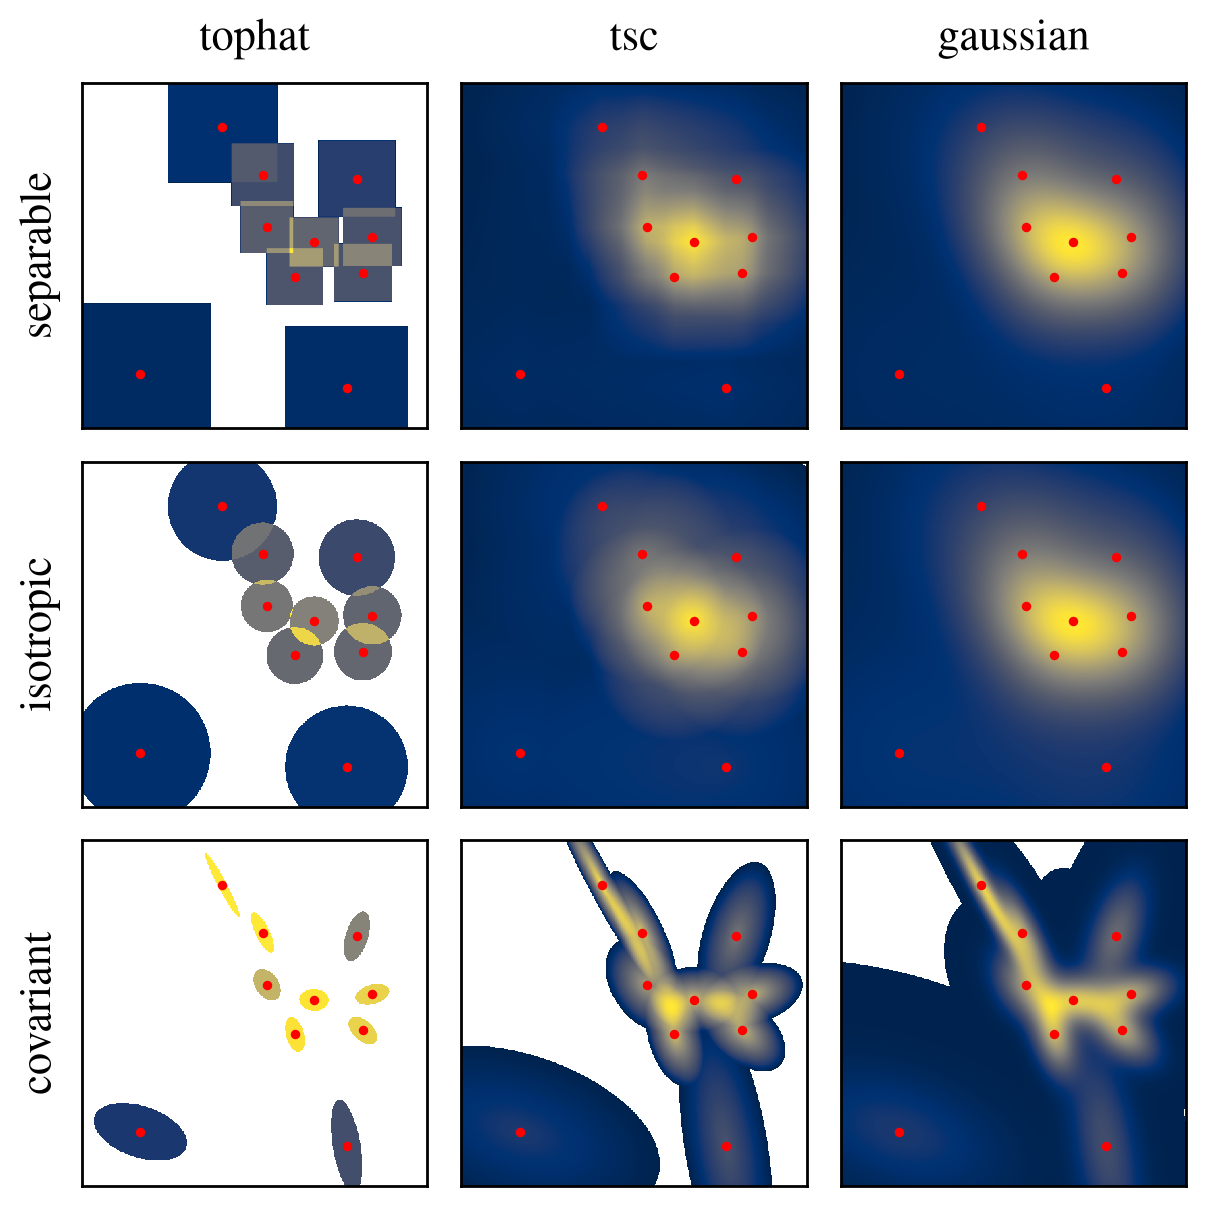

In [ ]:
fig, ax = plt.subplots(
    len(structures),
    len(kernel_names),
    figsize=(3, 3),
    sharex=True,
    sharey=True,
    layout='constrained'
    )

c = 0
for i, structure in enumerate(structures):
    for j, kernel_name in enumerate(kernel_names):
        F = adaptive_maps[c]
        ax[i, j].pcolormesh(F, vmin=0, vmax=np.nanmax(F), cmap='cividis')
        ax[i, j].scatter(positions[:, 1] * gridnums,
                         positions[:, 0] * gridnums,
                         c='r', s=2)
        ax[i, j].set_aspect('equal')
        ax[i, j].set(xticks=[], yticks=[])
        ax[0, j].set_title(f'{kernel_name}')
        c += 1

    ax[i, 0].set_ylabel(f'{structure}')

fig.savefig("adaptive.png", dpi=500, bbox_inches="tight", transparent=False)
#plt.close()

```{image} adaptive.png
:width: 80%
:align: center
```